<p style="align: center;"><img align=center src="https://s8.hostingkartinok.com/uploads/images/2018/08/308b49fcfbc619d629fe4604bceb67ac.jpg" width=500 height=450/></p>

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Полносвязные и свёрточные нейронные сети</b></h3>

В этом занятии вам предстоит потренироваться построению нейронных сетей с помощью библиотеки Pytorch. Делать мы это будем на нескольких датасетах.








In [261]:
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F

from torch.utils.data import TensorDataset, DataLoader

sns.set(style="darkgrid", font_scale=1.4)
SEED = 1
torch.manual_seed(SEED) #Я надеюсь, что это позволит всяким DataLoader выбирать всегда одинаковые подвыборки для батчей

# Часть 1. Датасет moons

Давайте сгенерируем датасет и посмотрим на него!

In [262]:
X, y = make_moons(n_samples=10000, random_state=42, noise=0.1)

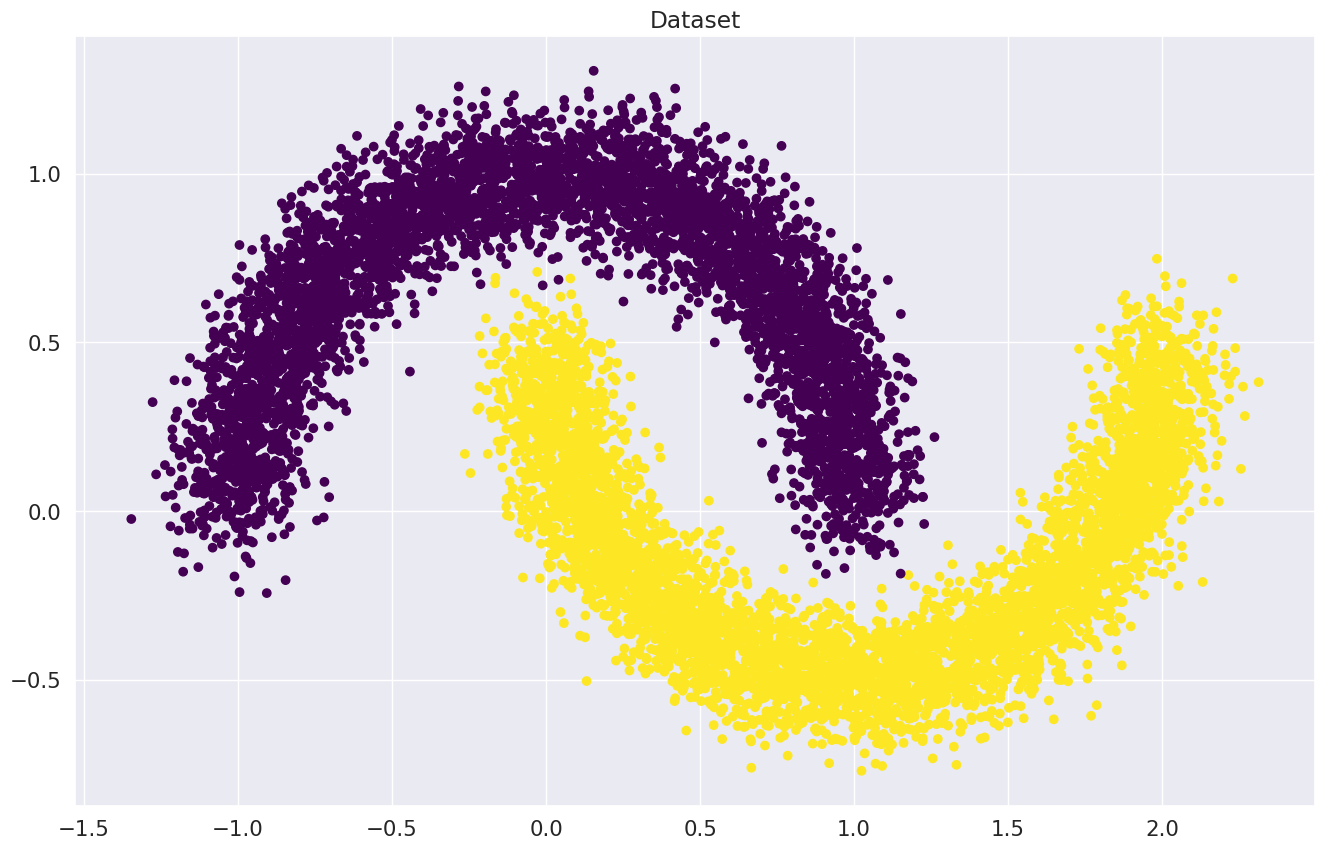

In [263]:
plt.figure(figsize=(16, 10))
plt.title("Dataset")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")
plt.show()

Сделаем train/test split

In [264]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

### Загрузка данных
В PyTorch загрузка данных как правило происходит налету (иногда датасеты не помещаются в оперативную память). Для этого используются две сущности `Dataset` и `DataLoader`.

1.   `Dataset` загружает каждый объект по отдельности.

2.   `DataLoader` группирует объекты из `Dataset` в батчи.

Так как наш датасет достаточно маленький мы будем использовать `TensorDataset`. Все, что нам нужно, это перевести из массива numpy в тензор с типом `torch.float32`.

### Задание. Создайте тензоры с обучающими и тестовыми данными

In [265]:
#YOUR CODE
#С использованием from_numpy имеем ссылочные переменные, т. е. X_train_t и X_train ссылаются на одну область памяти,
#изменение одного приведёт к изменению другого. Так как от нас требуется создать тензоры типа float32, а from_numpy
#использует тип оригинального numpy списка - float64, используем функцию type, которая возвращает копию тензора с новым типом.
X_train_t = torch.from_numpy(X_train).type('torch.FloatTensor')
y_train_t = torch.from_numpy(y_train).type('torch.FloatTensor')
X_val_t = torch.from_numpy(X_val).type('torch.FloatTensor')
y_val_t = torch.from_numpy(y_val).type('torch.FloatTensor')

Создаем `Dataset` и `DataLoader`.

In [266]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_dataloader = DataLoader(train_dataset, batch_size=128)
val_dataloader = DataLoader(val_dataset, batch_size=128)

## Logistic regression is my profession

**Напоминание**
Давайте вспоним, что происходит в логистической регрессии. На входе у нас есть матрица объект-признак X и столбец-вектор $y$ – метки из $\{0, 1\}$ для каждого объекта. Мы хотим найти такую матрицу весов $W$ и смещение $b$ (bias), что наша модель $XW + b$ будет каким-то образом предсказывать класс объекта. Как видно на выходе наша модель может выдавать число в интервале от $(-\infty;\infty)$. Этот выход как правило называют "логитами" (logits). Нам необходимо перевести его на интервал от $[0;1]$ для того, чтобы он выдавал нам вероятность принадлежности объекта к кассу один, также лучше, чтобы эта функция была монотонной, быстро считалась, имела производную и на $-\infty$ имела значение $0$, а на $+\infty$ имела значение $1$. Такой класс функций называется сигмоидыю. Чаще всего в качестве сигмоида берут
$$
\sigma(x) = \frac{1}{1 + e^{-x}}.
$$

### Задание. Реализация логистической регрессии

Вам необходимо написать модуль на PyTorch реализующий $logits = XW + b$, где $W$ и $b$ – параметры (`nn.Parameter`) модели. Иначе говоря, здесь мы реализуем своими руками модуль `nn.Linear` (в этом пункте его использование запрещено). Инициализируйте веса нормальным распределением (`torch.randn`).

In [337]:
class LinearRegression(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        #YOUR CODE
        self.weights = nn.Parameter(torch.randn(in_features, out_features, dtype=torch.float32))
        self.bias = bias
        if bias:
            self.bias_term = nn.Parameter(torch.randn(out_features, dtype=torch.float32))

    def forward(self, x):
        #YOUR CODE
        x = x @ self.weights
        if self.bias:
            x += self.bias_term
        return x

In [268]:
linear_regression = LinearRegression(2, 1)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.05)

**Вопрос 1.** Сколько обучаемых параметров у получившейся модели? Имеется в виду суммарное количество отдельных числовых переменных, а не количество тензоров.

In [269]:
#numel - количество элементов в input тензора
sum(p.numel() for p in linear_regression.parameters() if p.requires_grad)

3

### Train loop

Вот псевдокод, который поможет вам разобраться в том, что происходит во время обучения

```python
for epoch in range(max_epochs):  # <----------- итерируемся по датасету несколько раз
    for x_batch, y_batch in dataset:  # <------ итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
        optimizer.zero_grad()  # <------------- обуляем градиенты модели
        outp = model(x_batch)  # <------------- получаем "логиты" из модели
        loss = loss_func(outp, y_batch)  # <--- считаем "лосс" для логистической регрессии
        loss.backward()  # <------------------- считаем градиенты
        optimizer.step()  # <------------------ делаем шаг градиентного спуска
        if convergence:  # <------------------- в случае сходимости выходим из цикла
            break
```

В коде ниже добавлено логирование `accuracy` и `loss`.

### Задание. Реализация цикла обучения

In [270]:
tol = 1e-3
losses = []
max_epochs = 100
prev_weights = torch.zeros_like(linear_regression.weights)
stop_it = False
for epoch in range(max_epochs):
    for it, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()
        #YOUR CODE
        #---------
        outp = linear_regression.forward(X_batch)
        loss = loss_function(outp, y_batch) #unsqeeze(1): size [128] -> size [128, 1], т. к. outp.size() = [128, 1]
        #---------
        loss.backward()
        losses.append(loss.detach().flatten()[0])
        optimizer.step()
        #YOUR CODE
        #---------
        probabilities = nn.Sigmoid()(outp)
        #---------
        preds = (probabilities > 0.5).type(torch.long)
        batch_acc = (preds.flatten() == y_batch).type(torch.float32).sum() / y_batch.size(0)

        if (it + epoch * len(train_dataloader)) % 100 == 0:
            print(f"Iteration: {it + epoch * len(train_dataloader)}\nBatch accuracy: {batch_acc}")
        current_weights = linear_regression.weights.detach().clone()
        if (prev_weights - current_weights).abs().max() < tol:
            print(f"\nIteration: {it + epoch * len(train_dataloader)}. Convergence. Stopping iterations.")
            stop_it = True
            break
        prev_weights = current_weights
    if stop_it:
        break

Iteration: 0
Batch accuracy: 0.6484375
Iteration: 100
Batch accuracy: 0.765625
Iteration: 200
Batch accuracy: 0.796875
Iteration: 300
Batch accuracy: 0.8828125
Iteration: 400
Batch accuracy: 0.8515625
Iteration: 500
Batch accuracy: 0.8984375
Iteration: 600
Batch accuracy: 0.859375
Iteration: 700
Batch accuracy: 0.828125
Iteration: 800
Batch accuracy: 0.84375

Iteration: 814. Convergence. Stopping iterations.


**Вопрос 2.** Сколько итераций потребовалось, чтобы алгоритм сошелся?

**Ответ:** 814

### Визуализируем результаты

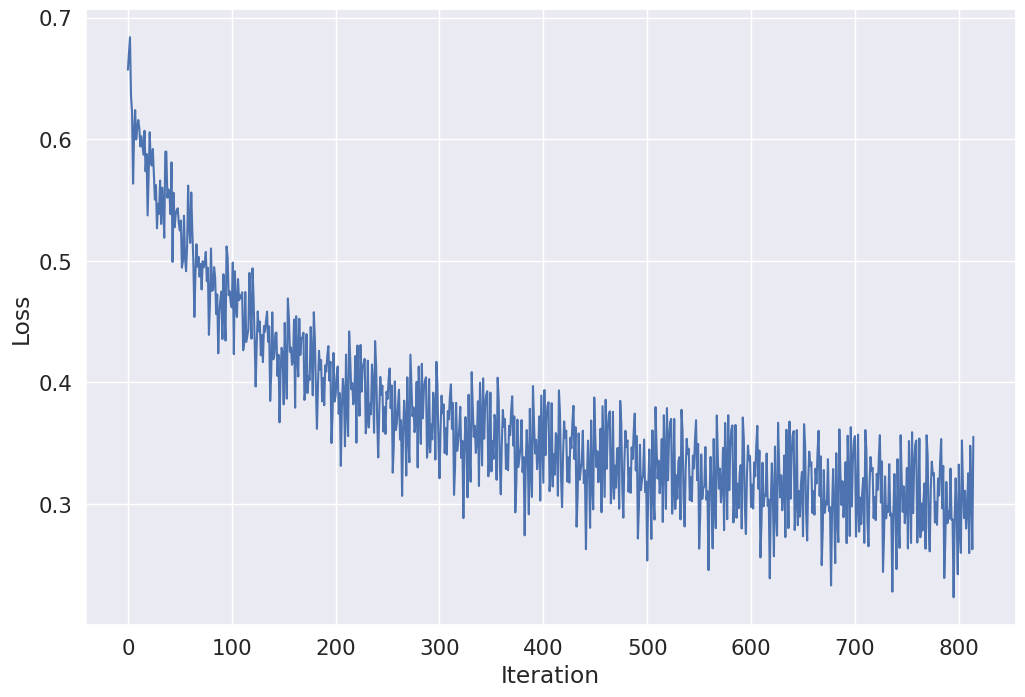

In [271]:
plt.figure(figsize=(12, 8))
plt.plot(range(len(losses)), losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

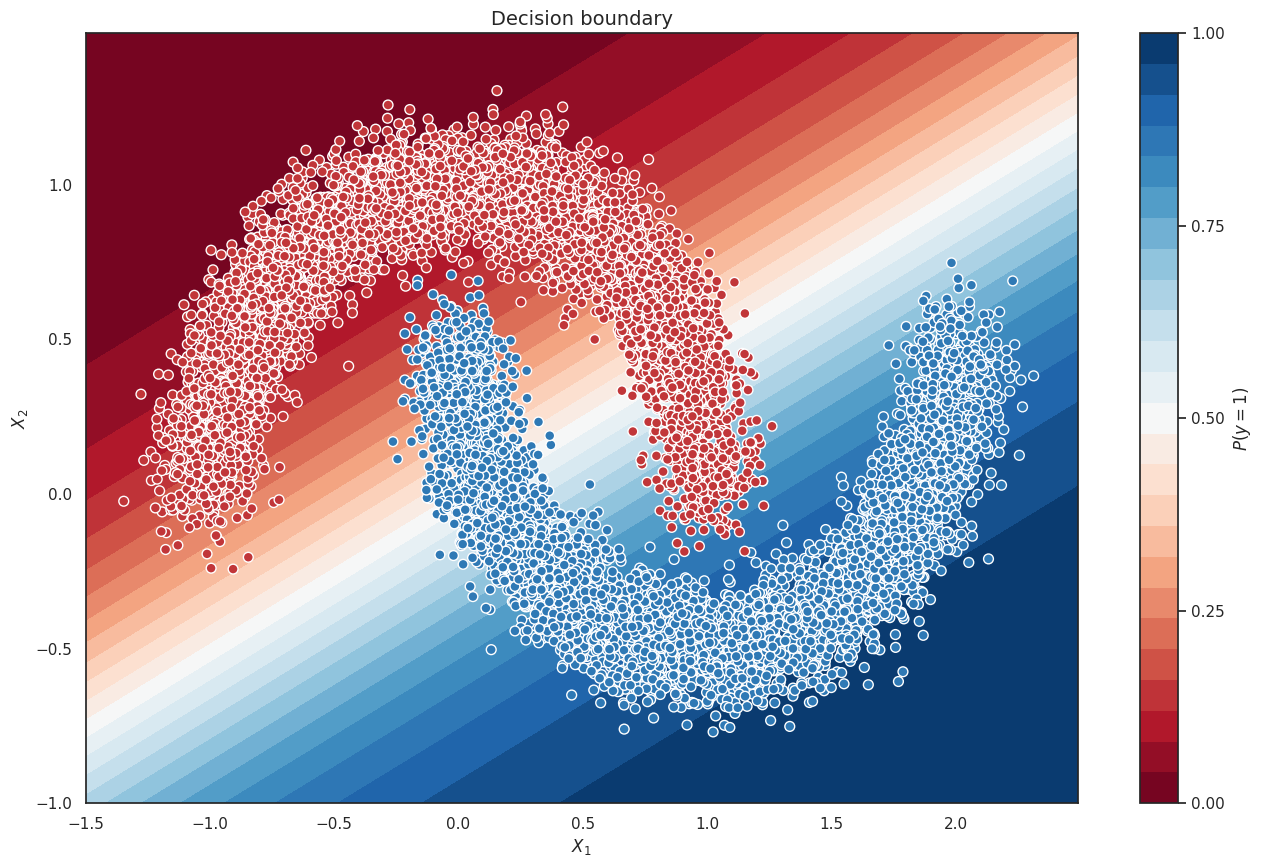

In [272]:
import numpy as np

sns.set(style="white")

xx, yy = np.mgrid[-1.5:2.5:.01, -1.:1.5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
batch = torch.from_numpy(grid).type(torch.float32)
with torch.no_grad():
    probs = torch.sigmoid(linear_regression(batch).reshape(xx.shape))
    probs = probs.numpy().reshape(xx.shape)

f, ax = plt.subplots(figsize=(16, 10))
ax.set_title("Decision boundary", fontsize=14)
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[100:,0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(xlabel="$X_1$", ylabel="$X_2$")
plt.show()

### Задание. Реализуйте predict и посчитайте accuracy на test.

In [273]:
@torch.no_grad()
def predict(dataloader, model):
    model.eval()
    predictions = np.array([])
    for x_batch, _ in dataloader:
        #YOUR CODE
        preds = (nn.Sigmoid()(model.forward(x_batch)) > 0.5).type(torch.long)
        predictions = np.hstack((predictions, preds.numpy().flatten()))
    return predictions.flatten()

In [274]:
from sklearn.metrics import accuracy_score

# YOUR CODE. Compute total accuracy
acc = (predict(val_dataloader, linear_regression) == y_val).astype(float).sum() / y_val.shape[0]
display(acc)

0.8608

**Вопрос 3**

Какое `accuracy` получается после обучения?

**Ответ:** 0.8608

# Часть 2. Датасет MNIST
Датасет MNIST содержит рукописные цифры. Загрузим датасет и создадим DataLoader-ы. Пример можно найти в семинаре по полносвязным нейронным сетям.

In [322]:
import os
from torchvision.datasets import MNIST
from torchvision import transforms as tfs


data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

# install for train and test
root = './'
train_dataset = MNIST(root, train=True,  transform=data_tfs, download=True)
val_dataset  = MNIST(root, train=False, transform=data_tfs, download=True)

#YOUR CODE надо ли писать размер батча? Ну я напишу, а то с дефолтным батчем
#размера 1 у меня 10 эпох для одной модели пол часа считались
batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, drop_last=True)
valid_dataloader = DataLoader(val_dataset, batch_size=batch_size, drop_last=True)

## Часть 2.1. Полносвязные нейронные сети
Сначала решим MNIST с помощью полносвязной нейронной сети.

In [338]:
class Identical(nn.Module):
    def forward(self, x):
        return x

### Задание. Простая полносвязная нейронная сеть

Создайте полносвязную нейронную сеть с помощью класса Sequential. Сеть состоит из:
* Уплощения матрицы в вектор (nn.Flatten);
* Двух скрытых слоёв из 128 нейронов с активацией nn.ELU;
* Выходного слоя с 10 нейронами.

Задайте лосс для обучения (кросс-энтропия).


In [339]:
#Чтобы задать первый скрытый слой, нужно знать сколько выходов у nn.Flatten.
#То есть просто посчитать количество фич картинки. MNIST возвращает tuple
#вида (image, target), где image - это какой-то tuple с двумя элементами,
#первый из которых - матрица изображения, а второй - какое-то непонятное число.
#Получается, для доступа к image, делаем train_dataset[0], а для доступа к матрице train_dataset[0][0]
features = np.array(train_dataset[0][0].shape).prod()

In [340]:
activation = nn.ELU

model = nn.Sequential(
    nn.Flatten(),
    #YOUR CODE. Add layers to your sequential class
    LinearRegression(features, 128),#nn.Linear(features, 128),
    activation(),
    LinearRegression(128, 128),#nn.Linear(128, 128),
    activation(),
    LinearRegression(128, 10)#nn.Linear(128, 10)
)

In [341]:
criterion = nn.CrossEntropyLoss() #YOUR CODE. Select a loss function
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

In [342]:
device = "cuda" if torch.cuda.is_available() else "cpu"

### Train loop (seriously)

Давайте разберемся с кодом ниже, который подойдет для 90% задач в будущем.


```python
for epoch in range(max_epochs):  # <--------------- итерируемся по датасету несколько раз
    for k, dataloader in loaders.items():  # <----- несколько dataloader для train / valid / test
        for x_batch, y_batch in dataloader:  # <--- итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
            if k == "train":
                model.train()  # <------------------ переводим модель в режим train
                optimizer.zero_grad()  # <--------- обнуляем градиенты модели
                outp = model(x_batch)
                loss = criterion(outp, y_batch) # <-считаем "лосс" для логистической регрессии
                loss.backward()  # <--------------- считаем градиенты
                optimizer.step()  # <-------------- делаем шаг градиентного спуска
            else:  # <----------------------------- test/eval
                model.eval()  # <------------------ переводим модель в режим eval
                with torch.no_grad():  # <--------- НЕ считаем градиенты
                    outp = model(x_batch)  # <------------- получаем "логиты" из модели
            count_metrics(outp, y_batch)  # <-------------- считаем метрики
```

### Задание. Дополните цикл обучения.

In [343]:
max_epochs = 10
accuracy = {"train": [], "valid": []}
for epoch in range(max_epochs):
    for k, dataloader in loaders.items():
        epoch_correct = 0
        epoch_all = 0
        for x_batch, y_batch in dataloader:
            if k == "train":
                 # YOUR CODE. Set model to ``train`` mode and calculate outputs. Don't forget zero_grad!
                 model.train()
                 optimizer.zero_grad()
                 outp = model(x_batch)
            else:
                 # YOUR CODE. Set model to ``eval`` mode and calculate outputs
                 model.eval()
                 with torch.no_grad():
                      outp = model(x_batch)
            preds = outp.argmax(-1)
            #YOUR CODE. Я вообще не понимаю почему приходится угадывать назначение переменных
            #---------
            correct = (preds == y_batch).sum() #Похоже здесь считаем количество верных ответов
            all = len(y_batch) #А здесь просто количество данных всего
            #---------
            epoch_correct += correct.item() #tensor.item() возвращает значение в тензоре, если оно единственное там
            epoch_all += all
            if k == "train":
                loss = criterion(outp, y_batch)
                # YOUR CODE. Calculate gradients and make a step of your optimizer
                loss.backward()
                optimizer.step()
        if k == "train":
            print(f"Epoch: {epoch+1}")
        print(f"Loader: {k}. Accuracy: {epoch_correct/epoch_all}")
        accuracy[k].append(epoch_correct/epoch_all)


Epoch: 1
Loader: train. Accuracy: 0.6237479967948718
Loader: valid. Accuracy: 0.8003806089743589
Epoch: 2
Loader: train. Accuracy: 0.8227664262820513
Loader: valid. Accuracy: 0.8560697115384616
Epoch: 3
Loader: train. Accuracy: 0.8610443376068376
Loader: valid. Accuracy: 0.8777043269230769
Epoch: 4
Loader: train. Accuracy: 0.8810763888888888
Loader: valid. Accuracy: 0.8866185897435898
Epoch: 5
Loader: train. Accuracy: 0.8948317307692307
Loader: valid. Accuracy: 0.8989383012820513
Epoch: 6
Loader: train. Accuracy: 0.9059662126068376
Loader: valid. Accuracy: 0.9071514423076923
Epoch: 7
Loader: train. Accuracy: 0.9154647435897436
Loader: valid. Accuracy: 0.9123597756410257
Epoch: 8
Loader: train. Accuracy: 0.9225093482905983
Loader: valid. Accuracy: 0.9160657051282052
Epoch: 9
Loader: train. Accuracy: 0.9283353365384616
Loader: valid. Accuracy: 0.921073717948718
Epoch: 10
Loader: train. Accuracy: 0.9337773771367521
Loader: valid. Accuracy: 0.9216746794871795


### Задание. Протестируйте разные функции активации.
Попробуйте разные функции активации. Для каждой функции активации посчитайте массив validation accuracy. Лучше реализовать это в виде функции, берущей на вход активацию и получающей массив из accuracies.

In [306]:
elu_accuracy = accuracy["valid"]

In [307]:
# YOUR CODE. Do the same thing with other activations (it's better to wrap into a function that returns a list of accuracies)

def test_activation_function(activation):
    #YOUR CODE
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(features, 128),
        activation(),
        nn.Linear(128, 128),
        activation(),
        nn.Linear(128, 10)
    )
    optimizer = torch.optim.Adam(model.parameters())
    max_epoch = 10
    accuracy = {"train": [], "valid": []}
    for epoch in range(max_epochs):
      for k, dataloader in loaders.items():
        epoch_correct = 0
        epoch_all = 0
        for x_batch, y_batch in dataloader:
          if k == "train":
            model.train()
            optimizer.zero_grad()
            outp = model(x_batch)
          else:
            model.eval()
            with torch.no_grad():
              outp = model(x_batch)
          preds = outp.argmax(-1)
          correct = (preds == y_batch).sum() #Похоже здесь считаем количество верных ответов
          all = len(y_batch) #А здесь просто количество данных всего
          epoch_correct += correct.item() #tensor.item() возвращает значение в тензоре, если оно единственное там
          epoch_all += all
          if k == "train":
            loss = criterion(outp, y_batch)
            loss.backward()
            optimizer.step()
        if k == "train":
          print(f"Epoch: {epoch+1}")
        print(f"Loader: {k}. Accuracy: {epoch_correct/epoch_all}")
        accuracy[k].append(epoch_correct/epoch_all)
    return accuracy["valid"]

In [308]:
print("With Identical activation")
plain_accuracy = test_activation_function(Identical)
print("---------")
#YOUR CODE
print("With ReLU activation")
relu_accuracy = test_activation_function(nn.ReLU)
print("---------")
print("With LeakyReLU activation")
leaky_relu_accuracy = test_activation_function(nn.LeakyReLU)

With Identical activation
Epoch: 1
Loader: train. Accuracy: 0.862129407051282
Loader: valid. Accuracy: 0.8866185897435898
Epoch: 2
Loader: train. Accuracy: 0.8957665598290598
Loader: valid. Accuracy: 0.8986378205128205
Epoch: 3
Loader: train. Accuracy: 0.900390625
Loader: valid. Accuracy: 0.8975360576923077
Epoch: 4
Loader: train. Accuracy: 0.9024939903846154
Loader: valid. Accuracy: 0.9002403846153846
Epoch: 5
Loader: train. Accuracy: 0.9040965544871795
Loader: valid. Accuracy: 0.9008413461538461
Epoch: 6
Loader: train. Accuracy: 0.9050313835470085
Loader: valid. Accuracy: 0.9008413461538461
Epoch: 7
Loader: train. Accuracy: 0.9064503205128205
Loader: valid. Accuracy: 0.9012419871794872
Epoch: 8
Loader: train. Accuracy: 0.9079193376068376
Loader: valid. Accuracy: 0.901542467948718
Epoch: 9
Loader: train. Accuracy: 0.9092214209401709
Loader: valid. Accuracy: 0.9021434294871795
Epoch: 10
Loader: train. Accuracy: 0.9101729433760684
Loader: valid. Accuracy: 0.9032451923076923
---------
Wi

### Accuracy
Построим график accuracy/epoch для каждой функции активации.

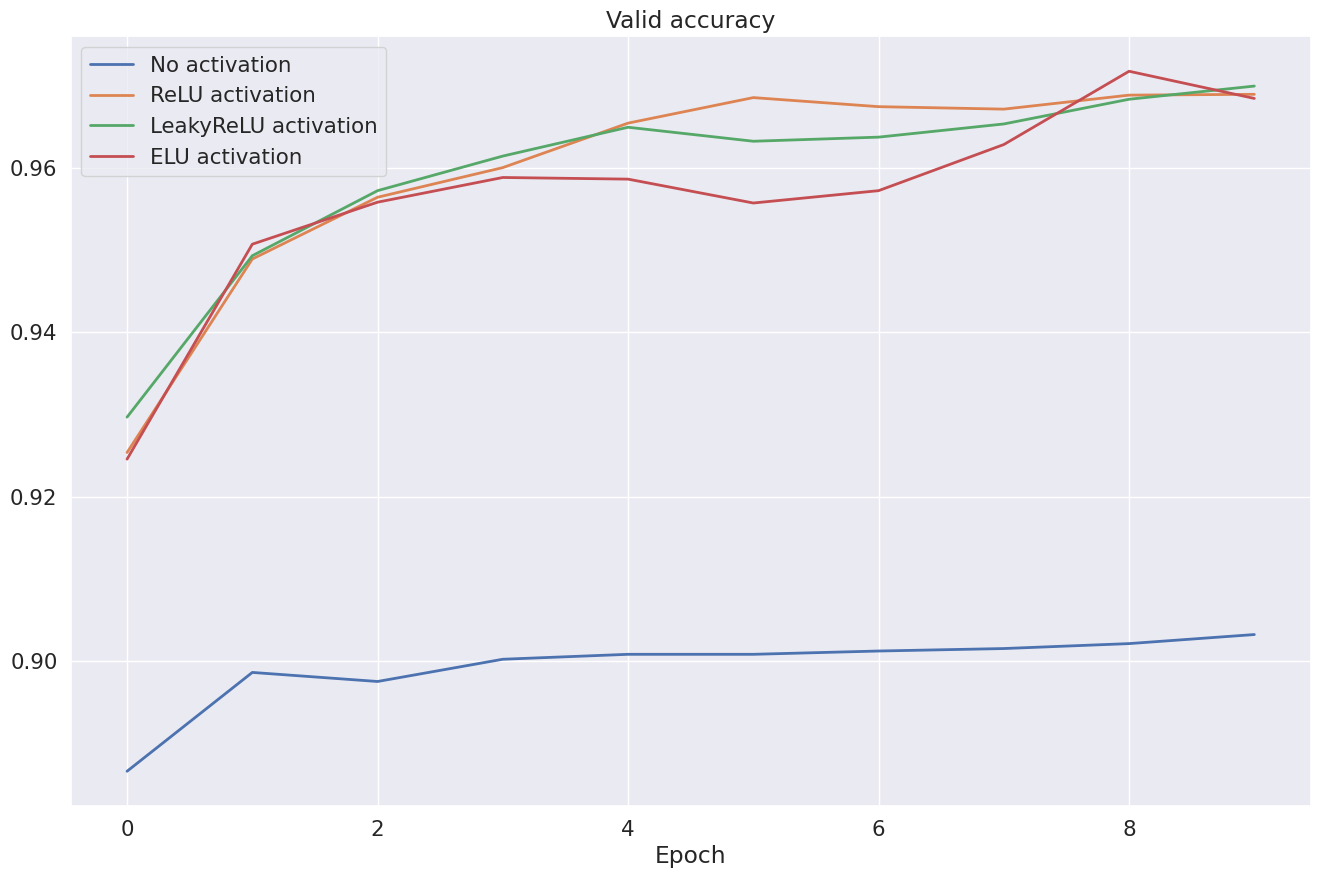

In [309]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), plain_accuracy, label="No activation", linewidth=2)
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

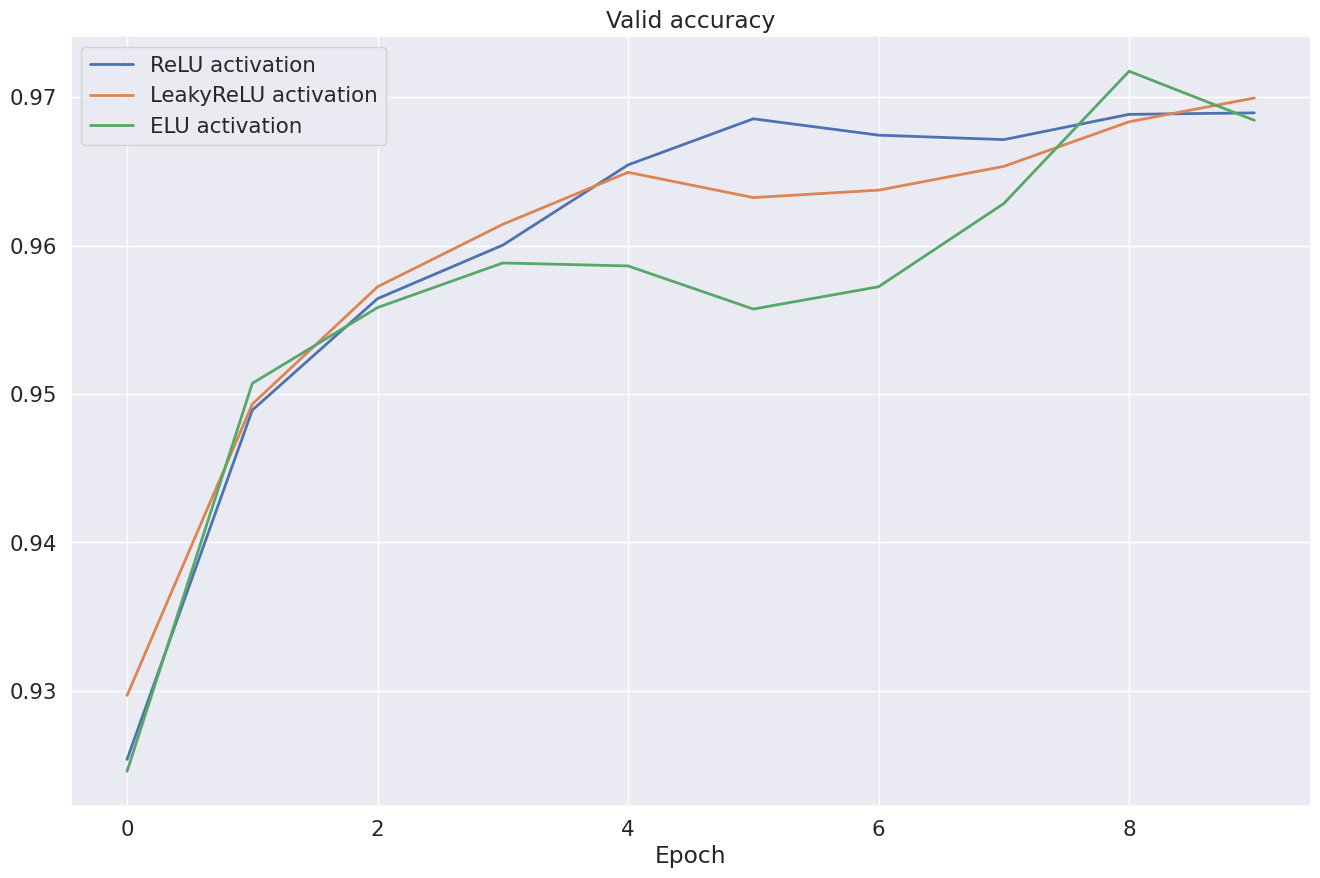

In [310]:
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 4.** Какая из активаций показала наивысший `accuracy` к концу обучения?

**Ответ:** LeakyReLU

## Часть 2.2 Сверточные нейронные сети

### Ядра
Сначала немного поработам с самим понятием ядра свёртки.

In [311]:
!wget https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg -O sample_photo.jpg

--2023-11-03 02:43:38--  https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg
Resolving img.the-village.kz (img.the-village.kz)... 5.9.226.237
Connecting to img.the-village.kz (img.the-village.kz)|5.9.226.237|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49337 (48K) [image/jpeg]
Saving to: ‘sample_photo.jpg’

sample_photo.jpg    100%[===================>]  48.18K   209KB/s    in 0.2s    

2023-11-03 02:43:39 (209 KB/s) - ‘sample_photo.jpg’ saved [49337/49337]



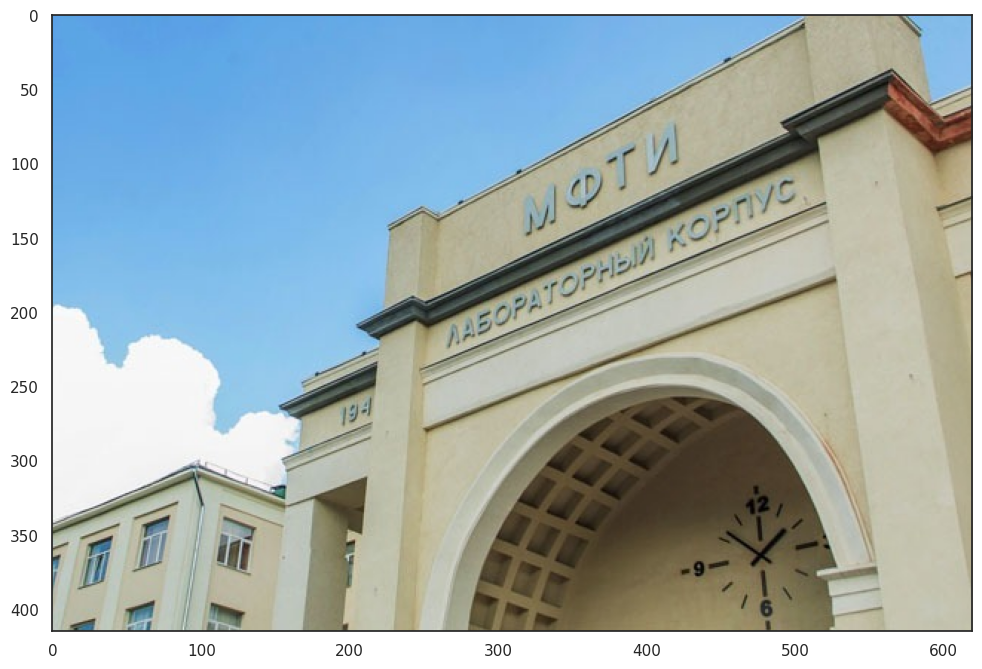

In [312]:
import cv2
sns.set(style="white")
img = cv2.imread("sample_photo.jpg")
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(RGB_img)
plt.show()

Попробуйте посмотреть как различные свертки влияют на фото. Например, попробуйте
A)
```
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]
```
Б)
```
[0, 1, 0],
[0, -2, 0],
[0, 1, 0]
```
В)
```
[0, 0, 0],
[1, -2, 1],
[0, 0, 0]
```
Г)
```
[0, 1, 0],
[1, -4, 1],
[0, 1, 0]
```
Д)
```
[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]
```
Е)
```
[0.0625, 0.125, 0.0625],
[0.125, 0.25, 0.125],
[0.0625, 0.125, 0.0625]
```

Не стесняйтесь пробовать свои варианты!

In [313]:
img_t = torch.from_numpy(RGB_img).type(torch.float32).unsqueeze(0)
kernel_a = torch.tensor([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
]).reshape(1, 1, 3, 3).type(torch.float32)
kernel_b = torch.tensor([
    [0, 1, 0],
    [0, -2, 0],
    [0, 1, 0]
]).reshape(1, 1, 3, 3).type(torch.float32)
kernel_c = torch.tensor([
    [0, 0, 0],
    [1, -2, 1],
    [0, 0, 0]
]).reshape(1, 1, 3, 3).type(torch.float32)
kernel_d = torch.tensor([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
]).reshape(1, 1, 3, 3).type(torch.float32)
kernel_e = torch.tensor([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
]).reshape(1, 1, 3, 3).type(torch.float32)
kernel_f = torch.tensor([
    [0.0625, 0.125, 0.0625],
    [0.125, 0.25, 0.125],
    [0.0625, 0.125, 0.0625]
]).reshape(1, 1, 3, 3).type(torch.float32)

kernels = [kernel_a, kernel_b, kernel_c, kernel_d, kernel_e, kernel_f]
img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size
result = []
result_np = []
for kernel in kernels:
  kernel = kernel.repeat(3, 3, 1, 1)
  result.append(F.conv2d(img_t, kernel)[0])
  result_np.append(result[-1].permute(1, 2, 0).numpy() / 256 / 3)

#kernel = kernel.repeat(3, 3, 1, 1)

#result = F.conv2d(img_t, kernel)[0]  #

In [314]:
import enum
fig, axes = plt.subplots(figsize=(72,48), nrows=len(kernels), ncols=1)
#plt.figure(figsize=(12, 8))
#result_np = result.permute(1, 2, 0).numpy() / 256 / 3

for num, res_np in enumerate(result_np):
  axes[num].imshow(res_np)

#plt.imshow(result_np)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Вопрос 5.** Как можно описать действия ядер, приведенных выше? Сопоставьте для каждой буквы число.

1) Размытие

2) Увеличение резкости

3) Тождественное преобразование

4) Выделение вертикальных границ

5) Выделение горизонтальных границ

6) Выделение границ

**Ответ:** 1) е, 2) д, 3) а, 4) в, 5) б, 6) г

### Задание. Реализуйте LeNet

Если мы сделаем параметры сверток обучаемыми, то можем добиться хороших результатов для задач компьютерного зрения. Реализуйте архитектуру LeNet, предложенную еще в 1998 году!
На этот раз используйте модульную структуру (без помощи класса Sequential).

Наша нейронная сеть будет состоять из
* Свёртки 3x3 (1 карта на входе, 6 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Свёртки 3x3 (6 карт на входе, 16 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Уплощения (nn.Flatten);
* Полносвязного слоя со 120 нейронами и активацией ReLU;
* Полносвязного слоя с 84 нейронами и активацией ReLU;
* Выходного слоя из 10 нейронов.




In [315]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(1, 6, 3)
        #YOUR CODE
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(400, 120) #ревьюер, помоги. Здесь должно быть три линейных слоя? В задании указано два, но если я не сделаю 400 на 120, у меня не сойдется количество нейронов
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        #YOUR CODE
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        #print(x.shape)
        #return "Error"
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [316]:
model = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

### Задание. Обучите CNN
Используйте код обучения, который вы написали для полносвязной нейронной сети.

In [317]:
#YOUR CODE
accuracy = {"train": [], "valid": []}
for epoch in range(max_epochs):
  for k, dataloader in loaders.items():
    epoch_correct = 0
    epoch_all = 0
    for x_batch, y_batch in dataloader:
      if k == "train":
        model.train()
        optimizer.zero_grad()
        outp = model(x_batch)
      else:
        model.eval()
        with torch.no_grad():
          outp = model(x_batch)
      preds = outp.argmax(-1)
      correct = (preds == y_batch).sum()
      epoch_correct += correct.item()
      epoch_all += len(y_batch)
      if k == "train":
        loss = criterion(outp, y_batch)
        loss.backward()
        optimizer.step()
    if k == "train":
      print(f"Epoch: {epoch+1}")
    print(f"Loader: {k}. Accuracy: {epoch_correct/epoch_all}")
    accuracy[k].append(epoch_correct/epoch_all)

Epoch: 1
Loader: train. Accuracy: 0.8709435096153846
Loader: valid. Accuracy: 0.9607371794871795
Epoch: 2
Loader: train. Accuracy: 0.9630909455128205
Loader: valid. Accuracy: 0.9732572115384616
Epoch: 3
Loader: train. Accuracy: 0.9748096955128205
Loader: valid. Accuracy: 0.9795673076923077
Epoch: 4
Loader: train. Accuracy: 0.980735844017094
Loader: valid. Accuracy: 0.9844751602564102
Epoch: 5
Loader: train. Accuracy: 0.984642094017094
Loader: valid. Accuracy: 0.9854767628205128
Epoch: 6
Loader: train. Accuracy: 0.9872128739316239
Loader: valid. Accuracy: 0.9856770833333334
Epoch: 7
Loader: train. Accuracy: 0.9893329326923077
Loader: valid. Accuracy: 0.9858774038461539
Epoch: 8
Loader: train. Accuracy: 0.9905515491452992
Loader: valid. Accuracy: 0.9862780448717948
Epoch: 9
Loader: train. Accuracy: 0.9928218482905983
Loader: valid. Accuracy: 0.9853766025641025
Epoch: 10
Loader: train. Accuracy: 0.9935396634615384
Loader: valid. Accuracy: 0.9846754807692307


In [318]:
lenet_accuracy = accuracy["valid"]

Сравним с предыдущем пунктом

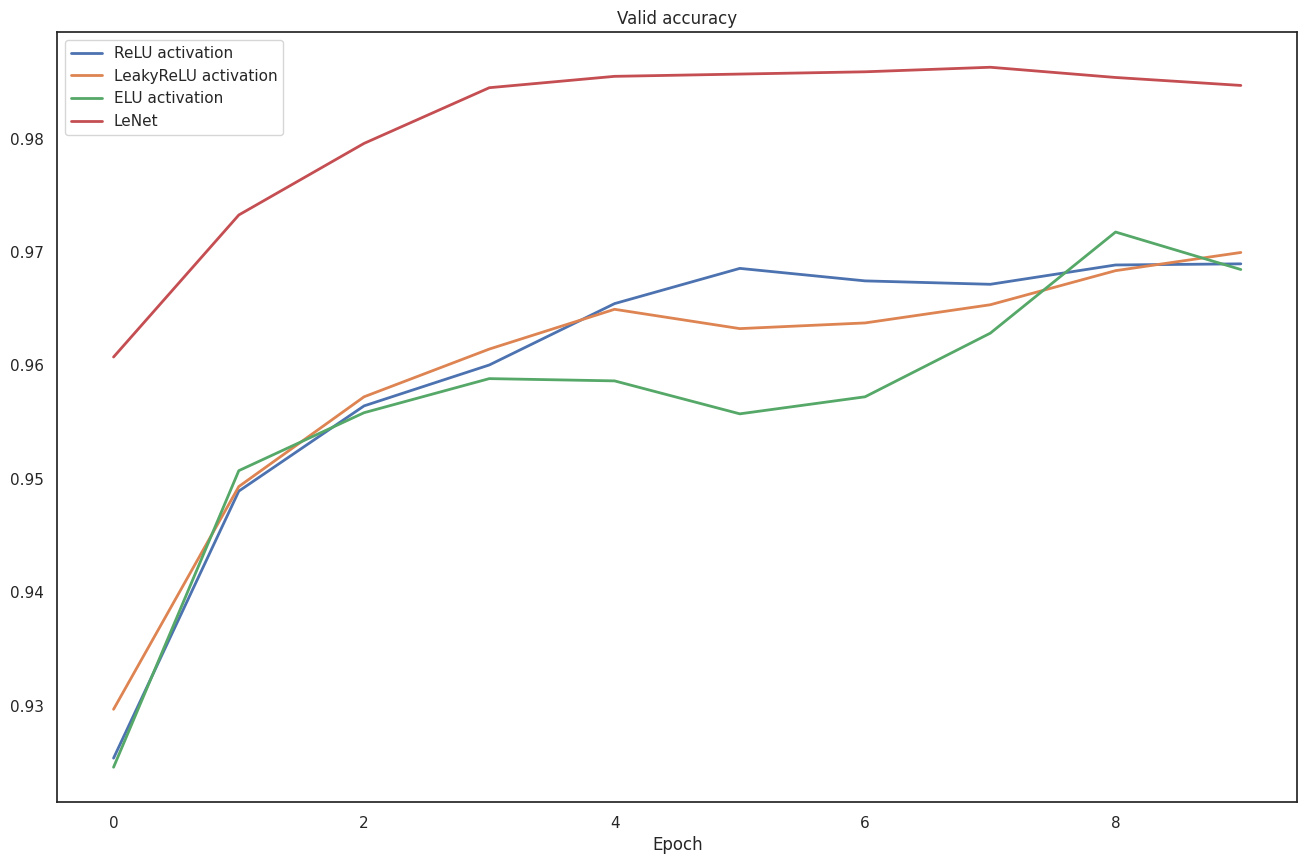

In [319]:
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.plot(range(max_epochs), lenet_accuracy, label="LeNet", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 6**
Какое `accuracy` получается после обучения с точностью до двух знаков после запятой?

**Ответ:** 0.99, если округлить